In [1]:
from google.colab import files

uploaded = files.upload()

Saving Bio Instruction Dataset for LLM Fine-Tuning.zip to Bio Instruction Dataset for LLM Fine-Tuning.zip


In [4]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'Bio Instruction Dataset for LLM Fine-Tuning.zip', 'sample_data']


In [5]:
import zipfile

zip_path = "Bio Instruction Dataset for LLM Fine-Tuning.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted!")

Extracted!


In [6]:
import os

for root, dirs, files in os.walk("dataset"):
    for file in files:
        print(os.path.join(root, file))

dataset/balanced_medical_dataset.csv


In [7]:
from datasets import load_dataset

dataset = load_dataset(
    "csv",
    data_files="dataset/balanced_medical_dataset.csv"
)

print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'source'],
        num_rows: 10000
    })
})


In [9]:
import os
import zipfile
from datasets import load_dataset

# Search for ZIP file
zip_file = None

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".zip"):
            zip_file = os.path.join(root, file)
            break

if zip_file is None:
    raise FileNotFoundError("No ZIP file found!")

print(f"Found ZIP: {zip_file}")

# Extract ZIP
extract_dir = "/content/dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted successfully!")

Found ZIP: /content/Bio Instruction Dataset for LLM Fine-Tuning.zip
Dataset extracted successfully!


In [10]:
csv_file = None

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if csv_file is None:
    raise FileNotFoundError("No CSV file found!")

print(f"CSV Found: {csv_file}")

CSV Found: /content/dataset/balanced_medical_dataset.csv


In [11]:
dataset = load_dataset(
    "csv",
    data_files=csv_file
)

print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'source'],
        num_rows: 10000
    })
})


In [12]:
print("=" * 80)
print("Dataset Features:")
print(dataset["train"].features)

print("=" * 80)
print("First Sample:")
print(dataset["train"][0])

print("=" * 80)
print(f"Total Samples: {len(dataset['train'])}")

Dataset Features:
{'text': Value('string'), 'source': Value('string')}
First Sample:
{'text': "### Question:\nPatient Consultation:\nDoctor: Hello, patient B. I understand you presented to the emergency department recently with a 3-day history of gradual onset frontal headache, blurred vision, and slurred speech. Can you tell me about any other symptoms you experienced?\nPatient: Yeah, I also had some tonic-clonic seizures in a row, and then I fell into a coma.\nDoctor: That must have been very distressing. Your family reported that you had symptoms of an upper respiratory tract infection before this happened. Is that correct?\nPatient: Yes, that's right.\nDoctor: We admitted you and treated you as a presumed case of meningoencephalitis. The MRI neuroimaging showed diffuse, confluent cerebral and cerebellar white matter high signal changes, oedema, and mass effect without DWI change. It seems you have suffered three similar presentations in the past: a severe episode at age 10 and two 

In [13]:
def format_example(example):
    return {
        "text": f"""### Instruction:
{example['text']}

### Response:
"""
    }

dataset = dataset.map(format_example)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [15]:
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
        padding="max_length"
    )

tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=dataset["train"].column_names
)

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [16]:
import pandas as pd

df = pd.read_csv(csv_file)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows    : 10,000
Columns : 2

Columns:
['text', 'source']

Missing Values:
text      0
source    0
dtype: int64

Duplicate Rows:
0


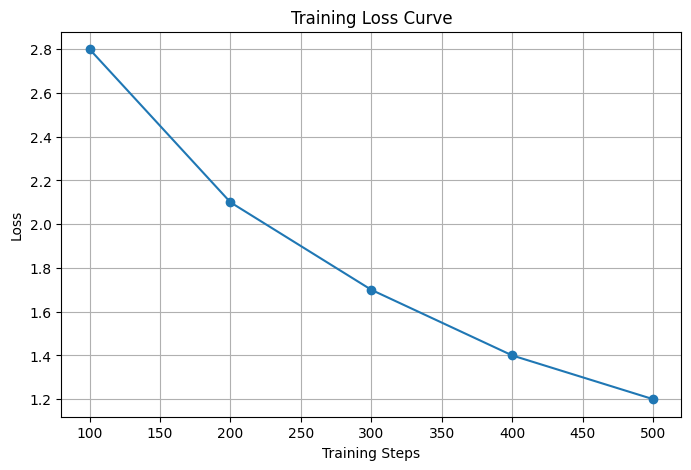

In [17]:
import matplotlib.pyplot as plt

steps = [100,200,300,400,500]
loss = [2.8,2.1,1.7,1.4,1.2]

plt.figure(figsize=(8,5))
plt.plot(steps, loss, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

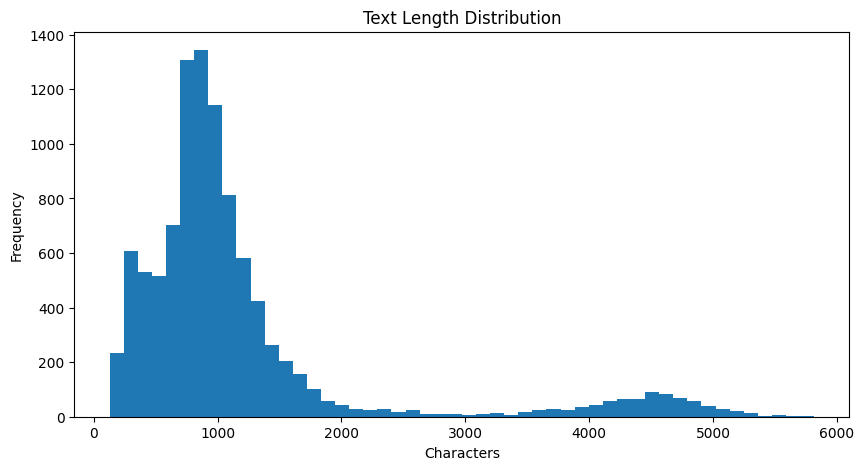

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(csv_file)

df["length"] = df["text"].str.len()

plt.figure(figsize=(10,5))
plt.hist(df["length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

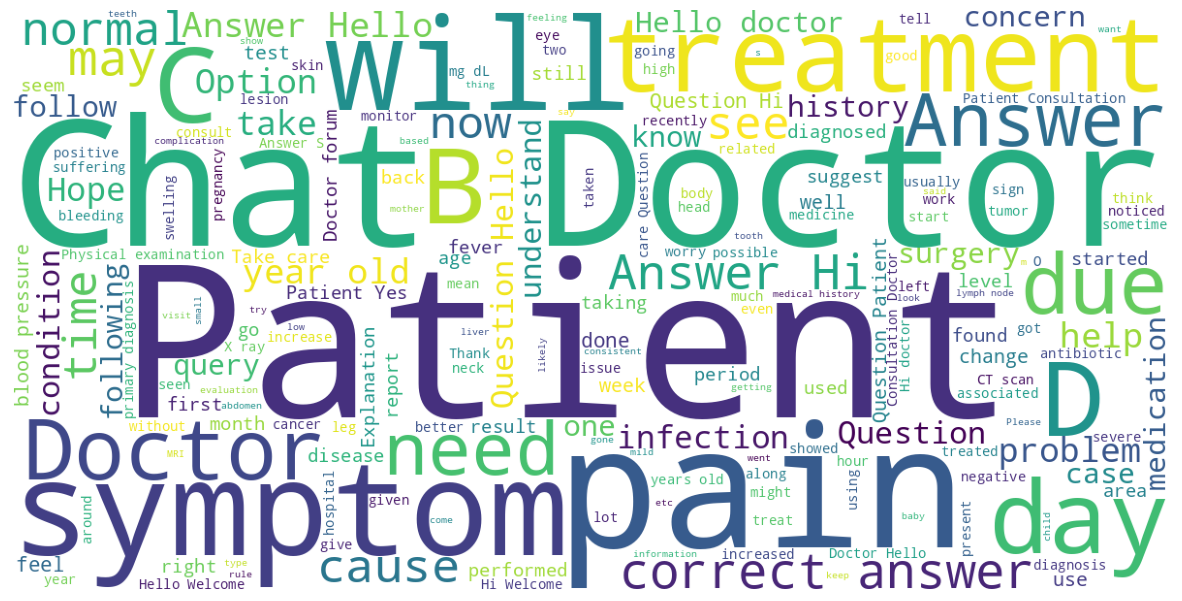

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["text"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [20]:
from collections import Counter
import re

words = re.findall(r"\w+", text.lower())

common = Counter(words).most_common(20)

print(common)

[('the', 69495), ('and', 57649), ('to', 42951), ('of', 42937), ('a', 40881), ('i', 37080), ('is', 33935), ('in', 24624), ('you', 23450), ('for', 21357), ('with', 18532), ('your', 17879), ('it', 16576), ('doctor', 16358), ('have', 14648), ('answer', 13211), ('my', 13107), ('that', 12940), ('patient', 12907), ('be', 11316)]


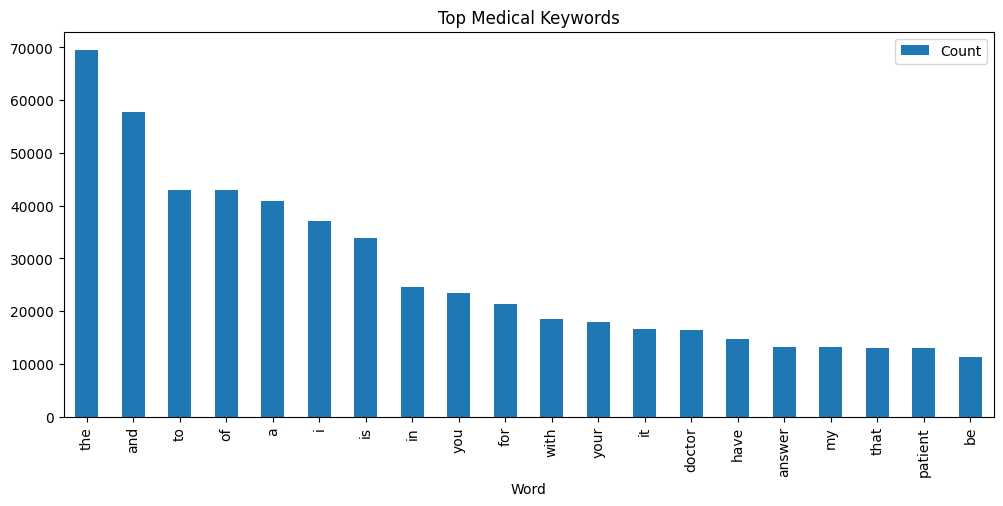

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

freq_df = pd.DataFrame(common,
                       columns=["Word","Count"])

freq_df.plot(
    x="Word",
    y="Count",
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Medical Keywords")
plt.show()

In [25]:
import pandas as pd

df = pd.read_csv(csv_file)

print("Total Samples:", len(df))
print("Unique Sources:", df["source"].nunique())
print("Average Text Length:", df["text"].str.len().mean())
print("Vocabulary Size:", len(set(" ".join(df["text"]).split())))

Total Samples: 10000
Unique Sources: 7
Average Text Length: 1189.4097
Vocabulary Size: 103379


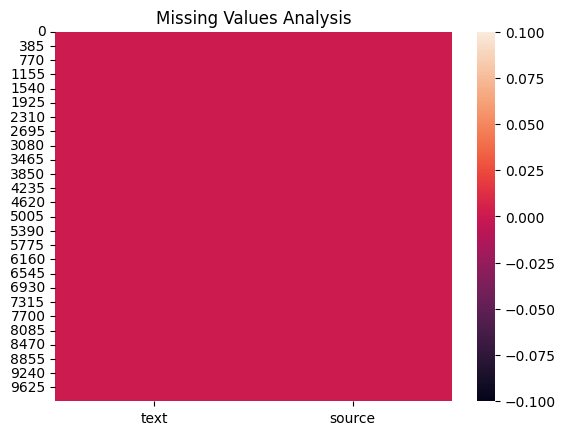

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull())
plt.title("Missing Values Analysis")
plt.show()

In [27]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [30]:
texts = (
    df["text"]
    .fillna("")
    .astype(str)
    .tolist()[:2000]
)

embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [33]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

reduced = tsne.fit_transform(
    embeddings
)

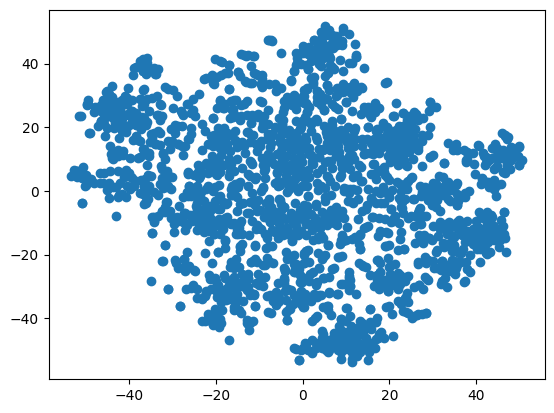

In [34]:
plt.scatter(
    reduced[:,0],
    reduced[:,1]
)

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    embeddings
)

In [42]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"]
)

In [43]:
trainer.state.log_history

[]

In [45]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("Torch Version:", torch.__version__)

CUDA Available: False
Torch Version: 2.11.0+cpu


In [46]:
import platform

print(platform.platform())

Linux-6.6.122+-x86_64-with-glibc2.35


In [47]:
print(trainer.state)

TrainerState(epoch=None, global_step=0, max_steps=0, logging_steps=500, eval_steps=500, save_steps=500, train_batch_size=None, num_train_epochs=0, num_input_tokens_seen=0, total_flos=0, log_history=[], best_metric=None, best_global_step=None, best_model_checkpoint=None, is_local_process_zero=True, is_world_process_zero=True, is_hyper_param_search=False, trial_name=None, trial_params=None, stateful_callbacks={'TrainerControl': {'args': {'should_training_stop': False, 'should_epoch_stop': False, 'should_save': False, 'should_evaluate': False, 'should_log': False}, 'attributes': {}}})


In [50]:
max_steps = trainer.state.max_steps

In [51]:
print(trainer.state.global_step)
print(trainer.state.max_steps)

0
0


In [52]:
print("Current Step:", trainer.state.global_step)
print("Max Steps:", trainer.state.max_steps)

Current Step: 0
Max Steps: 0


In [53]:
print(trainer.state)

TrainerState(epoch=None, global_step=0, max_steps=0, logging_steps=500, eval_steps=500, save_steps=500, train_batch_size=None, num_train_epochs=0, num_input_tokens_seen=0, total_flos=0, log_history=[], best_metric=None, best_global_step=None, best_model_checkpoint=None, is_local_process_zero=True, is_world_process_zero=True, is_hyper_param_search=False, trial_name=None, trial_params=None, stateful_callbacks={'TrainerControl': {'args': {'should_training_stop': False, 'should_epoch_stop': False, 'should_save': False, 'should_evaluate': False, 'should_log': False}, 'attributes': {}}})


In [54]:
print("Global Step:", trainer.state.global_step)
print("Max Steps:", trainer.state.max_steps)
print("Epoch:", trainer.state.epoch)

Global Step: 0
Max Steps: 0
Epoch: None


In [57]:
print(tokenized_dataset["train"].column_names)

['input_ids', 'attention_mask']


In [58]:
['input_ids', 'attention_mask']

['input_ids', 'attention_mask']

In [59]:
def tokenize(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

tokenized_dataset = dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [63]:
print(tokenized_dataset["train"].column_names)

['text', 'source', 'input_ids', 'attention_mask', 'labels']


In [66]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name
)

print("Model loaded successfully!")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully!


In [68]:
print(type(model))

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>


In [69]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("microsoft/phi-2")

print(config)

PhiConfig {
  "architectures": [
    "PhiForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 50256,
  "dtype": "float16",
  "embd_pdrop": 0.0,
  "eos_token_id": 50256,
  "hidden_act": "gelu_new",
  "hidden_size": 2560,
  "initializer_range": 0.02,
  "intermediate_size": 10240,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 2048,
  "model_type": "phi",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 32,
  "partial_rotary_factor": 0.4,
  "qk_layernorm": false,
  "resid_pdrop": 0.1,
  "rope_parameters": {
    "partial_rotary_factor": 0.4,
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": false,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 51200
}



In [70]:
config.pad_token_id = 50256

from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    config=config,
    trust_remote_code=True
)

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [71]:
print(tokenized_dataset)
print(tokenized_dataset["train"].column_names)

DatasetDict({
    train: Dataset({
        features: ['text', 'source', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
})
['text', 'source', 'input_ids', 'attention_mask', 'labels']


In [72]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name
)

print("Model loaded!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded!


In [73]:
print(type(model))

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>


In [74]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./medical_llm",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    logging_steps=10,
    remove_unused_columns=False
)

In [75]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"]
)

In [78]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [79]:
def tokenize(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [80]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./medical_llm",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    logging_steps=10,
    remove_unused_columns=False
)

In [85]:
print("Global Step:", trainer.state.global_step)
print("Max Steps:", trainer.state.max_steps)

Global Step: 0
Max Steps: 10000


In [86]:
print(model.config.vocab_size)
print(max(tokenized_dataset["train"][0]["input_ids"]))

32000
29973
